# Evaluacion Parcial 2: Analisis Exploratorio
Esta libreta contiene el analisis exploratorio de datos (EDA) para predecir si un cliente suscribira un deposito a plazo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid", palette="muted")
os.makedirs('graficos', exist_ok=True)

df = pd.read_csv('bank-additional-full.csv', sep=';')
df = df.drop_duplicates()

# Descartar 'duration' por recomendacion del diccionario de datos
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])

# 1. TRADUCCION DE VALORES CATEGORICOS
value_replacements = {
    'y': {'yes': 'si', 'no': 'no'},
    'contact': {'cellular': 'celular', 'telephone': 'telefono_fijo'},
    'poutcome': {'success': 'exito', 'failure': 'fracaso', 'nonexistent': 'inexistente'},
    'month': {'jan': 'ene', 'feb': 'feb', 'mar': 'mar', 'apr': 'abr', 'may': 'may', 
              'jun': 'jun', 'jul': 'jul', 'aug': 'ago', 'sep': 'sep', 'oct': 'oct', 
              'nov': 'nov', 'dec': 'dic'},
    'job': {'admin.': 'administrador', 'blue-collar': 'obrero', 'entrepreneur': 'emprendedor', 
            'housemaid': 'empleada_hogar', 'management': 'gerencia', 'retired': 'jubilado', 
            'self-employed': 'independiente', 'services': 'servicios', 'student': 'estudiante', 
            'technician': 'tecnico', 'unemployed': 'desempleado', 'unknown': 'desconocido'},
    'marital': {'married': 'casado', 'single': 'soltero', 'divorced': 'divorciado', 'unknown': 'desconocido'},
    'education': {'basic.4y': 'basica_4a', 'basic.6y': 'basica_6a', 'basic.9y': 'basica_9a', 
                  'high.school': 'secundaria', 'illiterate': 'analfabeto', 
                  'professional.course': 'curso_profesional', 'university.degree': 'universitario', 
                  'unknown': 'desconocido'},
    'default': {'yes': 'si', 'no': 'no', 'unknown': 'desconocido'},
    'housing': {'yes': 'si', 'no': 'no', 'unknown': 'desconocido'},
    'loan': {'yes': 'si', 'no': 'no', 'unknown': 'desconocido'}
}

for col, mapping in value_replacements.items():
    if col in df.columns:
        df[col] = df[col].replace(mapping)

# 2. TRADUCCION DE NOMBRES DE COLUMNAS
rename_columns = {
    'y': 'deposito_plazo',
    'age': 'edad',
    'job': 'trabajo',
    'marital': 'estado_civil',
    'education': 'educacion',
    'default': 'mora',
    'housing': 'vivienda',
    'loan': 'prestamo',
    'contact': 'contacto',
    'month': 'mes',
    'day_of_week': 'dia_de_la_semana',
    'campaign': 'campana',
    'pdays': 'dias_previos',
    'previous': 'anterior',
    'poutcome': 'resultado_anterior',
    'emp.var.rate': 'var_empleo',
    'cons.price.idx': 'indice_precios',
    'cons.conf.idx': 'indice_confianza',
    'euribor3m': 'tasa_euribor',
    'nr.employed': 'num_empleados'
}
df = df.rename(columns=rename_columns)

# 3. VARIABLE OBJETIVO NUMERICA
# Convertimos 'deposito_plazo' a numerica (1 y 0) para habilitar calculos estadisticos. 
df['deposito_plazo_num'] = df['deposito_plazo'].map({'si': 1, 'no': 0})

print("Datos cargados, limpios y traducidos al espanol con exito.")

Datos cargados, limpios y traducidos al espanol con exito.


## Introducción: El Reto del Negocio
Actualmente, el banco enfrenta un desafío crítico: la campaña de marketing telefónico para captar depósitos a plazo es costosa y altamente ineficiente. Se están invirtiendo enormes recursos humanos y de tiempo en llamar a miles de clientes, pero la gran mayoría de estas interacciones terminan en rechazo.

Para optimizar nuestra estrategia y dejar de operar a ciegas, este análisis exploratorio busca responder una sola pregunta central: **¿Qué características exactas tiene un cliente que finalmente dice "sí"?**

In [2]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('deposito_plazo_num')
cat_cols = df.select_dtypes(include=['object']).columns.drop('deposito_plazo')

num_corrs = []
for col in numeric_cols:
    corr = np.abs(df[col].corr(df['deposito_plazo_num']))
    num_corrs.append((col, corr))

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_corrs = []
for col in cat_cols:
    corr = cramers_v(df[col], df['deposito_plazo_num'])
    cat_corrs.append((col, corr))

all_corrs = num_corrs + cat_corrs
all_corrs.sort(key=lambda x: x[1], reverse=True)

print("Top 10 Variables mas relevantes:")
top_features = []
for i, (col, corr) in enumerate(all_corrs[:10]):
    print(f"{i+1}. {col} (Puntuacion: {corr:.4f})")
    top_features.append(col)

Top 10 Variables mas relevantes:
1. num_empleados (Puntuacion: 0.3547)
2. dias_previos (Puntuacion: 0.3249)
3. resultado_anterior (Puntuacion: 0.3204)
4. tasa_euribor (Puntuacion: 0.3077)
5. var_empleo (Puntuacion: 0.2983)
6. mes (Puntuacion: 0.2741)
7. anterior (Puntuacion: 0.2302)
8. trabajo (Puntuacion: 0.1520)
9. contacto (Puntuacion: 0.1446)
10. indice_precios (Puntuacion: 0.1361)


C:\Users\Carlos\AppData\Local\Temp\ipykernel_20736\2865015680.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.drop('deposito_plazo')


## Fase 1: El Problema y el Mapa
En esta primera etapa, establecemos visualmente la gravedad del problema.

### Grafico 1: Distribucion de la Variable Objetivo
**Justificacion:** Utilizamos un grafico de torta para establecer la linea base visual del proyecto. El analisis revela que el escenario es critico: solo tenemos cerca del 11% de conversiones exitosas, lo que demuestra la necesidad urgente de optimizar la estrategia usando los datos que veremos a continuacion.

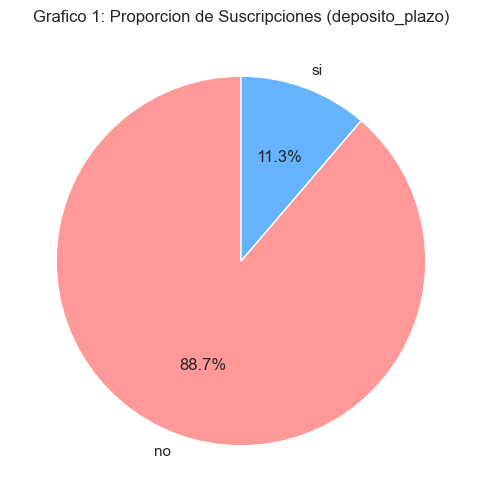

In [3]:
# Grafico 1: Distribucion de deposito_plazo
plt.figure(figsize=(6, 6))
df['deposito_plazo'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=90)
plt.title('Grafico 1: Proporcion de Suscripciones (deposito_plazo)')
plt.ylabel('')
plt.savefig('graficos/grafico_01.png', bbox_inches='tight')
plt.show()

### Grafico 2: Correlacion con la Variable Objetivo
**Justificacion:** Dado el problema crítico evidenciado en el gráfico anterior, necesitamos una brújula. En lugar de adivinar qué factores importan, diseñamos un algoritmo que evalúa matemáticamente todas las variables contra nuestro objetivo (usando Coeficiente de Pearson para numéricas y V de Cramer para categóricas). El gráfico resultante nos da el "mapa" oficial de los factores que explican estadísticamente el fracaso o el éxito.

C:\Users\Carlos\AppData\Local\Temp\ipykernel_20736\2792036122.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corrs_df, x='Correlacion', y='Variable', palette='coolwarm')


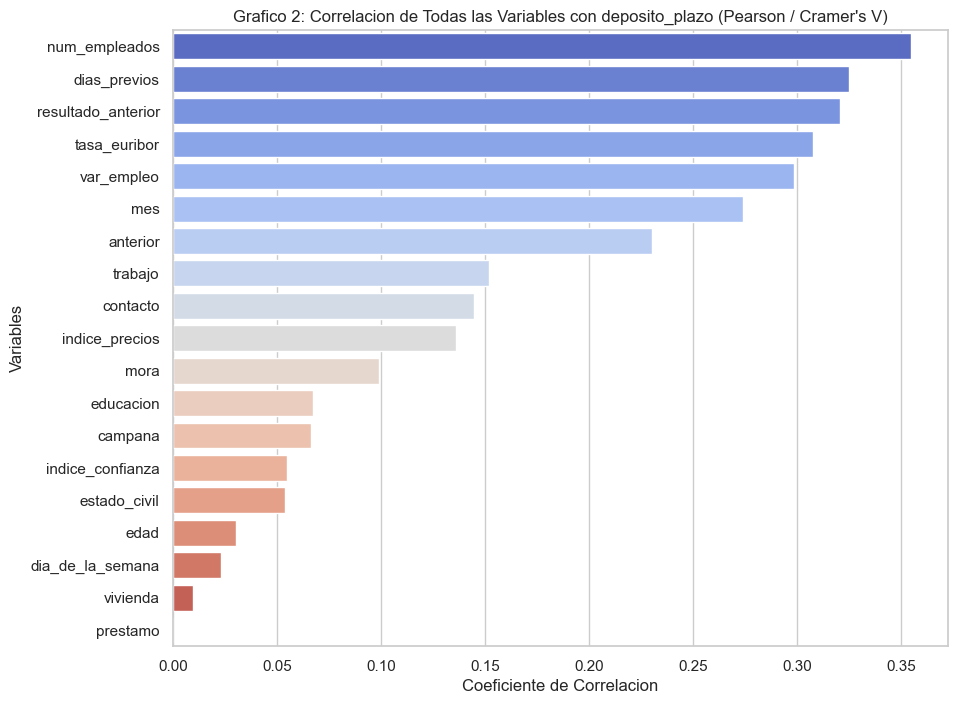

In [4]:
# Grafico 2: Correlacion de todas las variables con la variable objetivo
plt.figure(figsize=(10, 8))
corrs_df = pd.DataFrame(all_corrs, columns=['Variable', 'Correlacion'])
sns.barplot(data=corrs_df, x='Correlacion', y='Variable', palette='coolwarm')
plt.title('Grafico 2: Correlacion de Todas las Variables con deposito_plazo (Pearson / Cramer\'s V)')
plt.xlabel('Coeficiente de Correlacion')
plt.ylabel('Variables')
plt.savefig('graficos/grafico_02.png', bbox_inches='tight')
plt.show()

## Fase 2: El Contexto Económico Manda
El mapa de correlación nos mostró claramente que las variables macroeconómicas externas son el factor más determinante para el éxito. Veamos exactamente por qué y cómo impactan en la decisión del cliente.

### Grafico 3: Distribucion del Numero de Empleados
**Justificacion:** Utilizamos un histograma con estimación de densidad (KDE) para visualizar en qué rangos exactos de empleo se concentra la aceptación del producto. El análisis revela que las conversiones se acumulan en escenarios de bajo nivel de empleo (5.000 - 5.100), sugiriendo que en tiempos de incertidumbre laboral, los clientes prefieren productos de ahorro seguros.

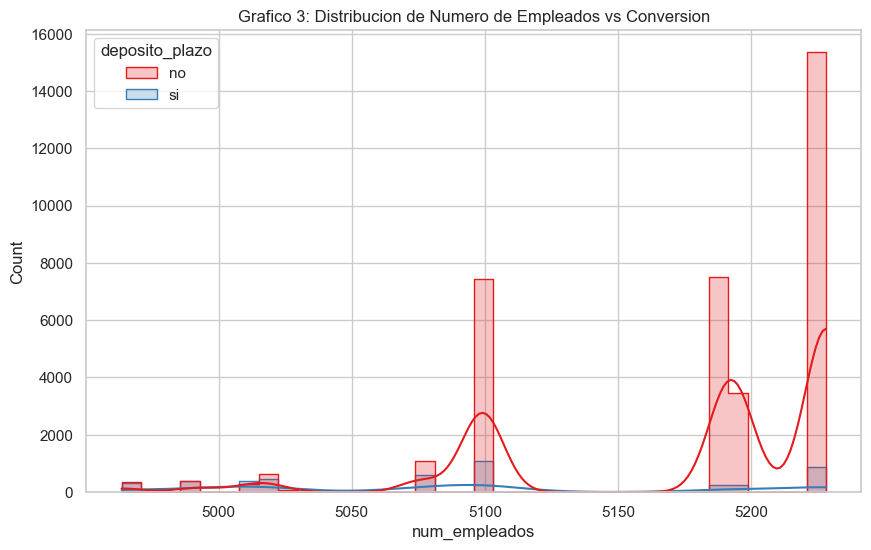

In [5]:
# Grafico 3: Distribucion de Empleados
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='num_empleados', hue='deposito_plazo', kde=True, palette='Set1', element='step', common_norm=False)
plt.title('Grafico 3: Distribucion de Numero de Empleados vs Conversion')
plt.savefig('graficos/grafico_03.png', bbox_inches='tight')
plt.show()

### Grafico 4: Impacto de Empleados en Conversion
**Justificacion:** El boxplot es ideal para comparar la mediana de una variable numerica frente a un resultado binario, eliminando el ruido de los valores atipicos. Confirma que la mediana de empleados es significativamente menor para los casos de exito, demostrando que el entorno macroeconomico adverso dicta la propension al ahorro.

C:\Users\Carlos\AppData\Local\Temp\ipykernel_20736\1676498438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='deposito_plazo', y='num_empleados', palette='Set2')


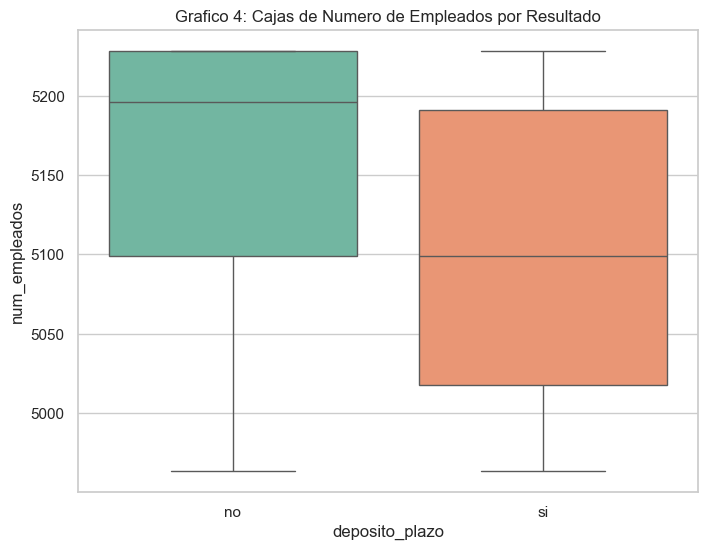

In [6]:
# Grafico 4: Boxplot de Empleados
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='deposito_plazo', y='num_empleados', palette='Set2')
plt.title('Grafico 4: Cajas de Numero de Empleados por Resultado')
plt.savefig('graficos/grafico_04.png', bbox_inches='tight')
plt.show()

### Grafico 5: Interaccion de Tasas
**Justificacion:** El scatterplot cruza dos variables numericas para observar como interactuan las tasas de interes con la variacion del empleo. Identificamos un fuerte cluster de exitos en el cuadrante inferior izquierdo, demostrando que tasas bajas combinadas con variacion negativa del empleo crean el ecosistema perfecto para la campana.

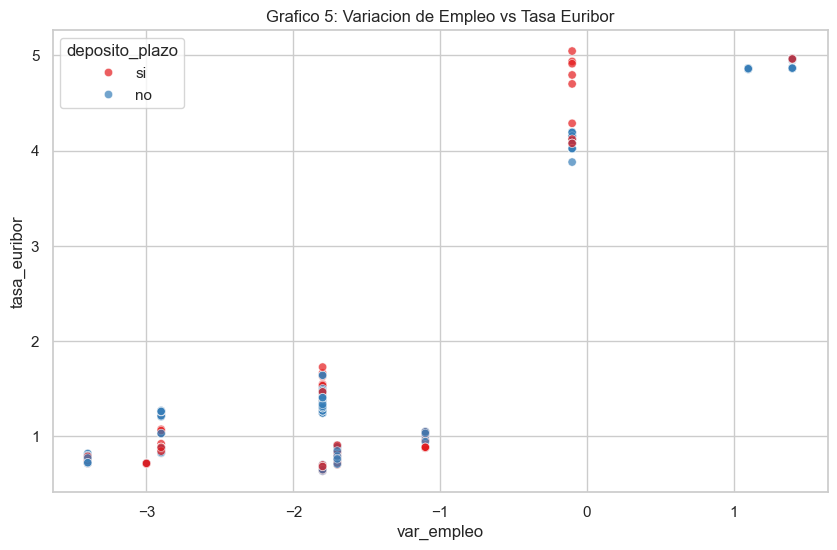

In [7]:
# Grafico 5: Scatterplot Macroeconomico
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000, random_state=42), x='var_empleo', y='tasa_euribor', hue='deposito_plazo', palette='Set1', alpha=0.7)
plt.title('Grafico 5: Variacion de Empleo vs Tasa Euribor')
plt.savefig('graficos/grafico_05.png', bbox_inches='tight')
plt.show()

### Grafico 6: Indice de Precios al Consumidor
**Justificacion:** Utilizamos un boxplot del Índice de Precios al Consumidor para validar si la inflación también acompaña el patrón macroeconómico. Si bien la diferencia es moderada (0.7 puntos en la mediana), los casos de éxito se concentran consistentemente en períodos de IPC ligeramente menor, lo que refuerza el patrón general: los clientes ahorran más cuando el entorno económico genera incertidumbre.

C:\Users\Carlos\AppData\Local\Temp\ipykernel_20736\2459836059.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='deposito_plazo', y='indice_precios', palette='Set3')


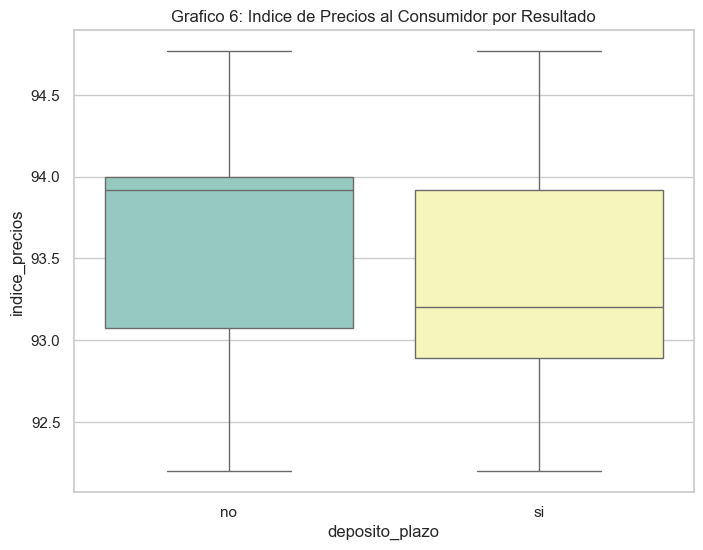

In [8]:
# Grafico 6: IPC Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='deposito_plazo', y='indice_precios', palette='Set3')
plt.title('Grafico 6: Indice de Precios al Consumidor por Resultado')
plt.savefig('graficos/grafico_06.png', bbox_inches='tight')
plt.show()

## Fase 3: El Historial del Cliente
Ya sabemos el *cuándo* económico ideal. Ahora, volviendo a nuestro mapa (Gráfico 2), vemos que el segundo factor más importante es el historial de interacciones previas. Evaluemos la eficacia de nuestra relación histórica con ellos.

### Grafico 7: Dias desde el Ultimo Contacto
**Justificacion:** Histograma filtrando los valores 999 (clientes nunca antes contactados) para analizar el tiempo de maduracion ideal de un prospecto. Los clientes contactados entre 3 y 6 días después de un intento previo muestran picos de conversión masivos (65.8%), mientras que dejar enfriar el contacto reduce significativamente la probabilidad de éxito."

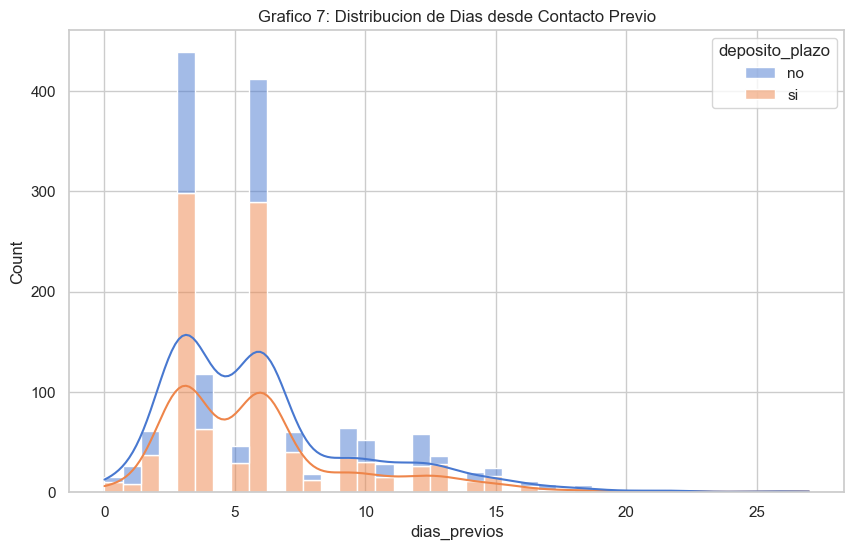

In [9]:
# Grafico 7: Distribucion de pdays
plt.figure(figsize=(10, 6))
df_contactados = df[df['dias_previos'] != 999]
sns.histplot(data=df_contactados, x='dias_previos', hue='deposito_plazo', kde=True, multiple="stack")
plt.title('Grafico 7: Distribucion de Dias desde Contacto Previo')
plt.savefig('graficos/grafico_07.png', bbox_inches='tight')
plt.show()

### Grafico 8: Resultado de la Campana Anterior
**Justificacion:** Barras agrupadas para contrastar frecuencias absolutas y medir el impacto directo del historial del cliente. Un cliente que mostro un resultado de 'exito' en una campana anterior tiene una altisima probabilidad de volver a suscribir un deposito.

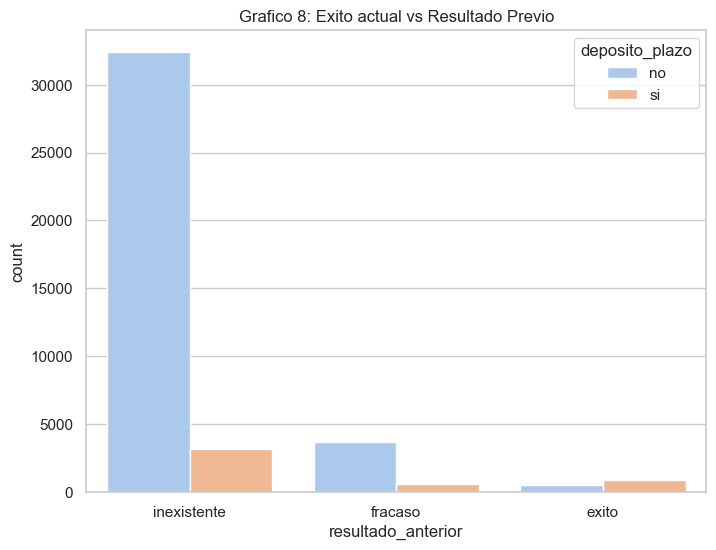

In [10]:
# Grafico 8: Barras resultado_anterior
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='resultado_anterior', hue='deposito_plazo', palette='pastel')
plt.title('Grafico 8: Exito actual vs Resultado Previo')
plt.savefig('graficos/grafico_08.png', bbox_inches='tight')
plt.show()

### Grafico 9: Numero de Contactos Previos
**Justificacion:** Barras apiladas al 100% para visualizar la proporción pura de conversión sin que las diferencias de volumen distorsionen el rendimiento. A medida que aumenta el historial de contactos previos, la franja de éxito porcentual crece agresivamente: de un 8.8% con cero contactos previos hasta un 72% con cinco o más, uno de los patrones más contundentes de todo el análisis.

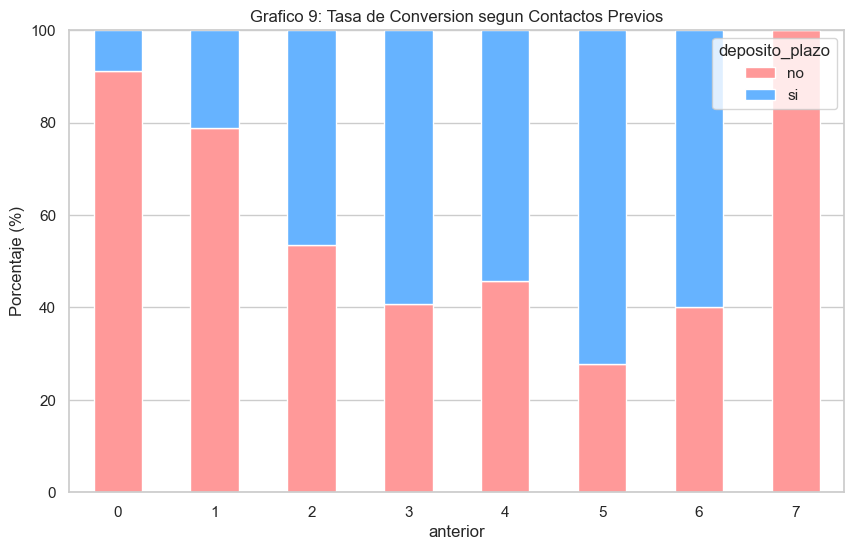

In [11]:
# Grafico 9: Barras apiladas anterior
plt.figure(figsize=(10, 6))
prev_res = pd.crosstab(df['anterior'], df['deposito_plazo'], normalize='index') * 100
prev_res.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=plt.gca())
plt.title('Grafico 9: Tasa de Conversion segun Contactos Previos')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.savefig('graficos/grafico_09.png', bbox_inches='tight')
plt.show()

### Grafico 10: Insistencia en la Campana Actual
**Justificacion:** Boxplot acotado para analizar la distribucion efectiva de los intentos en la campana actual requeridos para lograr una conversion. La caja se concentra entre 1 y 3 llamadas, demostrando que insistir mas veces solo satura al cliente y gasta recursos operativos.

C:\Users\Carlos\AppData\Local\Temp\ipykernel_20736\2722349974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='deposito_plazo', y='campana', palette='deep')


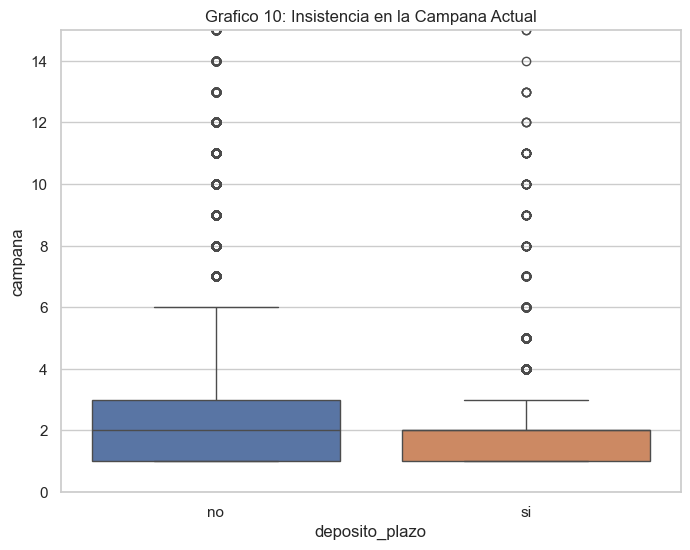

In [12]:
# Grafico 10: Boxplot campana
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='deposito_plazo', y='campana', palette='deep')
plt.ylim(0, 15)
plt.title('Grafico 10: Insistencia en la Campana Actual')
plt.savefig('graficos/grafico_10.png', bbox_inches='tight')
plt.show()

## Fase 4: El Perfil y el Canal
Finalmente, asumiendo que llamamos en el contexto económico correcto y respetando el historial del cliente, nos queda responder la pregunta táctica final para nuestra fuerza de ventas: ¿a quién llamamos exactamente y por qué canal?

### Grafico 11: Volumen por Mes
**Justificacion:** Conteo de volumen en bruto ordenado cronológicamente para auditar la distribución del trabajo operativo a lo largo del año. Se evidencia que el banco concentra una cantidad abrumadora de recursos casi exclusivamente en mayo, revelando un sesgo operativo que deja desatendidos meses estratégicos como marzo, octubre y diciembre, que aunque de menor volumen, superan el 43% de tasa de conversión. La recomendación no es abandonar mayo, sino redistribuir parte del presupuesto hacia esos meses antes de que se saturen.

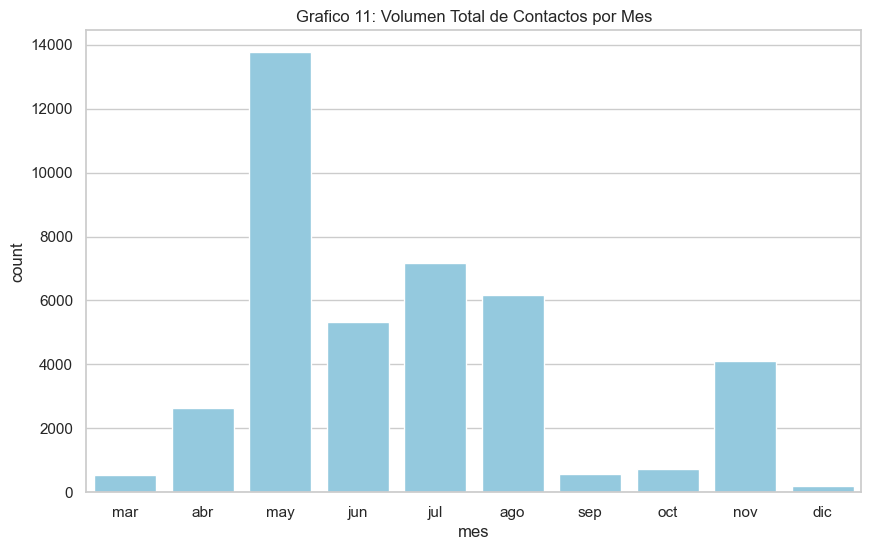

In [13]:
# Grafico 11: Mes Volumen
plt.figure(figsize=(10, 6))
order_months = ['mar', 'abr', 'may', 'jun', 'jul', 'ago', 'sep', 'oct', 'nov', 'dic']
sns.countplot(data=df, x='mes', order=order_months, color='skyblue')
plt.title('Grafico 11: Volumen Total de Contactos por Mes')
plt.savefig('graficos/grafico_11.png', bbox_inches='tight')
plt.show()

### Grafico 12: Tasa de Conversion por Mes
**Justificacion:** Grafico de lineas para evaluar la eficiencia en el tiempo destacando picos de rendimiento. Revela una paradoja: Mayo tiene el mayor volumen de llamadas pero la peor tasa de conversion, mientras que meses como marzo, septiembre y diciembre son mucho mas eficientes.

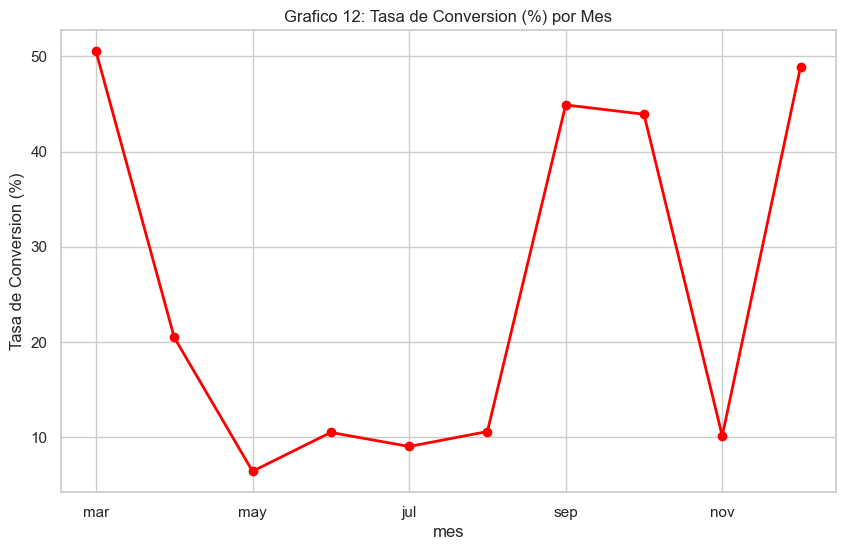

In [14]:
# Grafico 12: Mes Conversion Linea
plt.figure(figsize=(10, 6))
conversion_rate = df.groupby('mes')['deposito_plazo_num'].mean().reindex(order_months) * 100
conversion_rate.plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('Grafico 12: Tasa de Conversion (%) por Mes')
plt.ylabel('Tasa de Conversion (%)')
plt.grid(True)
plt.savefig('graficos/grafico_12.png', bbox_inches='tight')
plt.show()

### Grafico 13: Trabajo
**Justificacion:** Barras horizontales que facilitan la lectura de las 12 categorías y comparan equitativamente la proporción de éxito. Aunque administradores y obreros dominan el volumen bruto, los estudiantes (31.4%) y jubilados (25.2%) son nuestro nicho más eficiente por tasa de conversión. Su volumen es menor, por lo que deben complementar y no reemplazar al segmento principal, pero representan el perfil prioritario cuando el contexto macroeconómico es favorable.

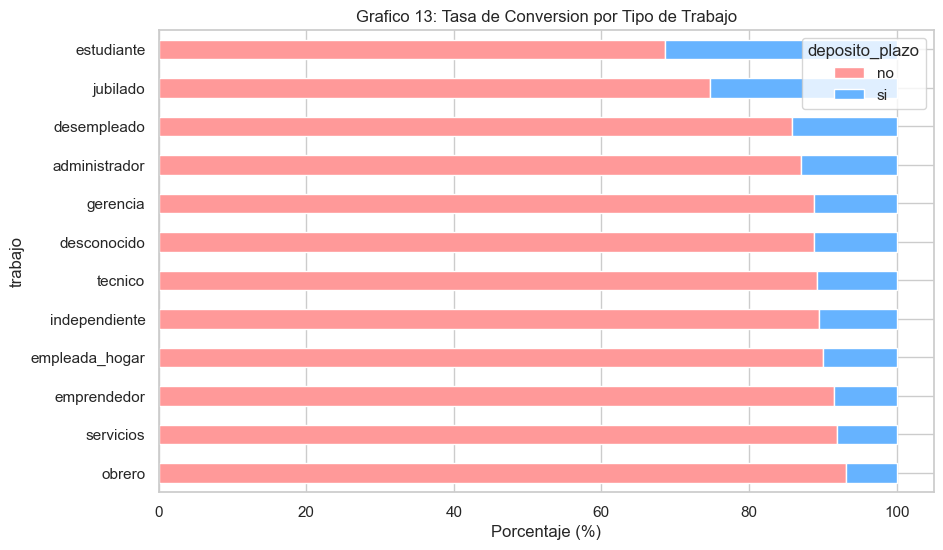

In [15]:
# Grafico 13: Trabajo
plt.figure(figsize=(10, 6))
job_res = pd.crosstab(df['trabajo'], df['deposito_plazo'], normalize='index') * 100
job_res.sort_values('si').plot(kind='barh', stacked=True, color=['#ff9999', '#66b3ff'], ax=plt.gca())
plt.title('Grafico 13: Tasa de Conversion por Tipo de Trabajo')
plt.xlabel('Porcentaje (%)')
plt.savefig('graficos/grafico_13.png', bbox_inches='tight')
plt.show()

### Grafico 14: Medio de Contacto
**Justificacion:** Compara el impacto del celular frente al telefono fijo aislando el tamano dispar de cada canal para evaluar la eficacia tecnologica. Contactar al cliente a traves de su celular tiene una tasa de conversion abrumadoramente superior al telefono fijo.

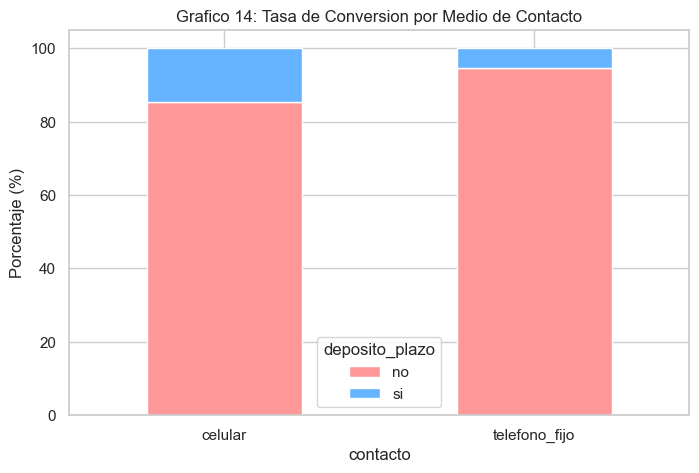

In [16]:
# Grafico 14: Contacto
plt.figure(figsize=(8, 5))
contact_res = pd.crosstab(df['contacto'], df['deposito_plazo'], normalize='index') * 100
contact_res.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=plt.gca())
plt.title('Grafico 14: Tasa de Conversion por Medio de Contacto')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.savefig('graficos/grafico_14.png', bbox_inches='tight')
plt.show()

### Grafico 15: Impacto Absoluto de Contacto
**Justificacion:** Conteo de la magnitud pura cruzando el trabajo y el canal de contacto exclusivamente sobre el subconjunto de exitos. Demuestra que incluso en perfiles de alto volumen, el celular aporta la gran mayoria del exito, dejando al telefono fijo obsoleto.

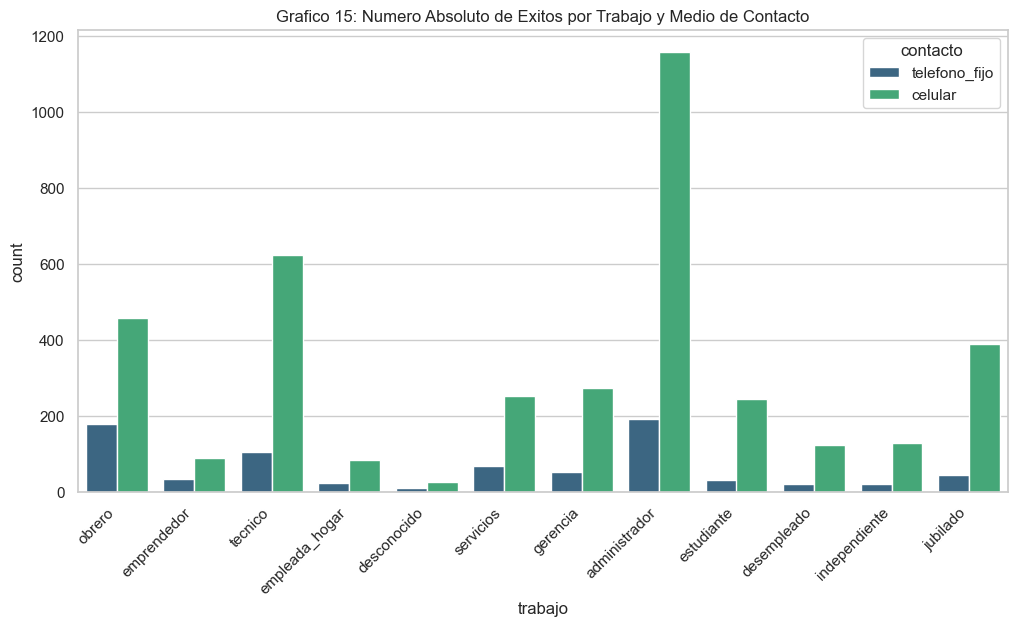

In [17]:
# Grafico 15: Conteo Absoluto
plt.figure(figsize=(12, 6))
df_yes = df[df['deposito_plazo'] == 'si']
sns.countplot(data=df_yes, x='trabajo', hue='contacto', palette='viridis')
plt.title('Grafico 15: Numero Absoluto de Exitos por Trabajo y Medio de Contacto')
plt.xticks(rotation=45, ha='right')
plt.savefig('graficos/grafico_15.png', bbox_inches='tight')
plt.show()

## Conclusión Estratégica
Tras explorar visualmente los datos y confirmarlos con nuestro mapa de correlación, la respuesta a nuestra pregunta inicial está clara. 

El **cliente ideal (con mayor probabilidad de conversión)** es aquel que cumple con las siguientes características:
1. **Contexto:** Es contactado durante un periodo de incertidumbre económica (tasas de interés bajas e inflación controlada), ya que el análisis muestra que este contexto macroeconómico correlaciona fuertemente con la conversión a productos de ahorro seguro.
2. **Momento:** Preferentemente es contactado en los meses de **marzo, septiembre, octubre o diciembre**, evitando por completo la saturación altamente ineficiente del mes de mayo.
3. **Perfil y Canal:** Es preferentemente un estudiante o jubilado, y **siempre** es contactado a través de su **teléfono celular** (el teléfono fijo ha demostrado ser obsoleto e inefectivo).
4. **Historial:** Es un cliente que idealmente ya dijo que "sí" en una campaña pasada, y no debemos insistirle más de 3 veces en la campaña actual para no quemar el recurso ni saturarlo.

Considerando que hoy operamos con una ineficiente tasa base del 11.3% de conversión, implementar estas restricciones como directrices duras en el CRM del banco podría fácilmente duplicar esa tasa, lo que representaría un ahorro masivo en los costos operativos y en el desgaste del equipo de Call Center.

## Anexo Técnico: Preprocesamiento Avanzado para Machine Learning
A continuación, se prepara el dataset validado para su eventual consumo por algoritmos predictivos. Este paso técnico no interrumpe el análisis, sino que lo habilita para despliegues futuros.

### Nota sobre Imputación de Valores Faltantes (Variable 'mora')
Para el preprocesamiento, aplicamos imputación por la moda (el valor más frecuente) a las variables categóricas que contienen el valor `'desconocido'`. 

Sin embargo, es crítico documentar que la variable **`mora` (default)** contiene aproximadamente un **20.9%** de valores desconocidos. Imputar silenciosamente más de un quinto de los datos de una variable asumiendo que todos son la moda puede introducir un sesgo significativo en el modelo predictivo final. 

En un entorno de producción avanzado, la recomendación técnica sería mantener `'desconocido'` como una categoría propia (ya que la ausencia de información financiera suele ser predictiva por sí misma) o utilizar técnicas de imputación multivariada. Para efectos de este anexo base, procedemos con la imputación por moda, pero dejamos constancia del riesgo de sesgo.

## Sección 1: Tratamiento de Datos Faltantes

En el dataset, los valores faltantes **no aparecen como NaN** sino que están enmascarados como la cadena `"desconocido"` (traducido de `"unknown"`). Esto es común en datos de contact centers, donde el operador simplemente no registra la información.

### Técnica seleccionada: Imputación por la Moda
Se optó por **imputación por la moda** (valor más frecuente) para las variables categóricas afectadas, en lugar de eliminación de filas, por las siguientes razones:
1. **Preservar información**: Las filas afectadas representan hasta el 20% del dataset; eliminarlas reduciría drásticamente el volumen de datos.
2. **Variables nominales sin orden**: Para variables como `trabajo`, `educacion` o `estado_civil`, no existe escala numérica, por lo que la moda es el estimador estadístico más adecuado.
3. **Consistencia del pipeline**: La imputación permite que el pipeline de ML procese todas las filas sin interrupciones.

In [18]:
# ─── DIAGNÓSTICO DE VALORES FALTANTES (unknowns) ───────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler

os.makedirs('graficos', exist_ok=True)

# Crear df_ml desde df limpio (sin modificar df original del EDA)
df_ml = df.copy()

cols_check = ['trabajo', 'estado_civil', 'educacion', 'mora', 'vivienda', 'prestamo']
desconocidos = {}
for col in cols_check:
    n = (df_ml[col] == 'desconocido').sum()
    pct = round(n / len(df_ml) * 100, 2)
    desconocidos[col] = {'Cantidad': n, 'Porcentaje (%)': pct}

tabla_faltantes = pd.DataFrame(desconocidos).T
tabla_faltantes = tabla_faltantes[tabla_faltantes['Cantidad'] > 0]
print("=== Variables con valores desconocidos ==================================")
print(tabla_faltantes.to_string())

=== Variables con valores desconocidos ==================================
              Cantidad  Porcentaje (%)
trabajo          330.0            0.80
estado_civil      80.0            0.19
educacion       1730.0            4.20
mora            8596.0           20.88
vivienda         990.0            2.40
prestamo         990.0            2.40


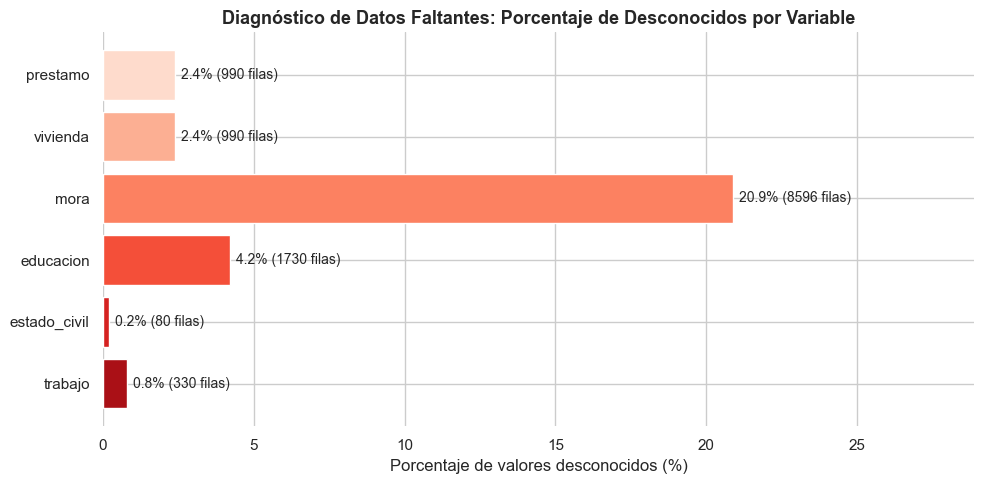

Gráfico guardado: datos_faltantes_diagnostico_unknowns.png


In [19]:
# ─── GRÁFICO: Valores Faltantes por Variable ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colores = sns.color_palette("Reds_r", len(tabla_faltantes))
bars = ax.barh(tabla_faltantes.index, tabla_faltantes['Porcentaje (%)'], color=colores, edgecolor='white')

for bar, (_, row) in zip(bars, tabla_faltantes.iterrows()):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{row['Porcentaje (%)']:.1f}% ({int(row['Cantidad'])} filas)",
            va='center', fontsize=10)

ax.set_xlabel('Porcentaje de valores desconocidos (%)')
ax.set_title('Diagnóstico de Datos Faltantes: Porcentaje de Desconocidos por Variable', fontsize=13, fontweight='bold')
ax.set_xlim(0, tabla_faltantes['Porcentaje (%)'].max() + 8)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('graficos/datos_faltantes_diagnostico_unknowns.png', bbox_inches='tight', dpi=150)
plt.show()
print("Gráfico guardado: datos_faltantes_diagnostico_unknowns.png")

In [20]:
# ─── IMPUTACIÓN POR LA MODA ──────────────────────────────────────────────────
print("\nAplicando imputación por moda en columnas con 'desconocido'...")
for col in cols_check:
    if 'desconocido' in df_ml[col].values:
        moda = df_ml[df_ml[col] != 'desconocido'][col].mode()[0]
        n_imputados = (df_ml[col] == 'desconocido').sum()
        df_ml[col] = df_ml[col].replace('desconocido', moda)
        print(f"  ✔ {col}: {n_imputados} valores → imputados con moda = '{moda}'")

# Verificación
restantes = {col: (df_ml[col] == 'desconocido').sum() for col in cols_check}
print("\n=== Verificación post-imputación (deben ser todos 0) ==================")
print(pd.Series(restantes).to_string())


Aplicando imputación por moda en columnas con 'desconocido'...
  ✔ trabajo: 330 valores → imputados con moda = 'administrador'
  ✔ estado_civil: 80 valores → imputados con moda = 'casado'
  ✔ educacion: 1730 valores → imputados con moda = 'universitario'
  ✔ mora: 8596 valores → imputados con moda = 'no'
  ✔ vivienda: 990 valores → imputados con moda = 'si'
  ✔ prestamo: 990 valores → imputados con moda = 'no'

=== Verificación post-imputación (deben ser todos 0) ==================
trabajo         0
estado_civil    0
educacion       0
mora            0
vivienda        0
prestamo        0


## Sección 2: Escalamiento de Variables Numéricas

El escalamiento es un paso crítico antes de aplicar algoritmos de Machine Learning como Regresión Logística, donde la magnitud de las variables afecta directamente el peso de los coeficientes.

### Proceso en dos pasos:

**Paso 1 — Capping de outliers (método IQR)**  
Antes de escalar, se capan las variables con outliers extremos usando el rango intercuartil (IQR). Un valor es outlier si está por debajo de Q1 − 1.5×IQR o por encima de Q3 + 1.5×IQR.  
Variables afectadas: `edad`, `campana`.

**Paso 2 — StandardScaler (Z-score)**  
Se estandariza cada variable numérica para que tenga **media = 0** y **desviación estándar = 1**.  
- **Justificación vs MinMaxScaler**: Con outliers presentes aun después del capping, StandardScaler es más robusto porque no colapsa la distribución hacia un rango fijo [0,1].  
- **Impacto**: Permite que la Regresión Logística y otros algoritmos converjan correctamente sin que variables de mayor escala (ej. `num_empleados` ≈ 5000) dominen sobre las pequeñas (ej. `anterior` ≈ 0–7).

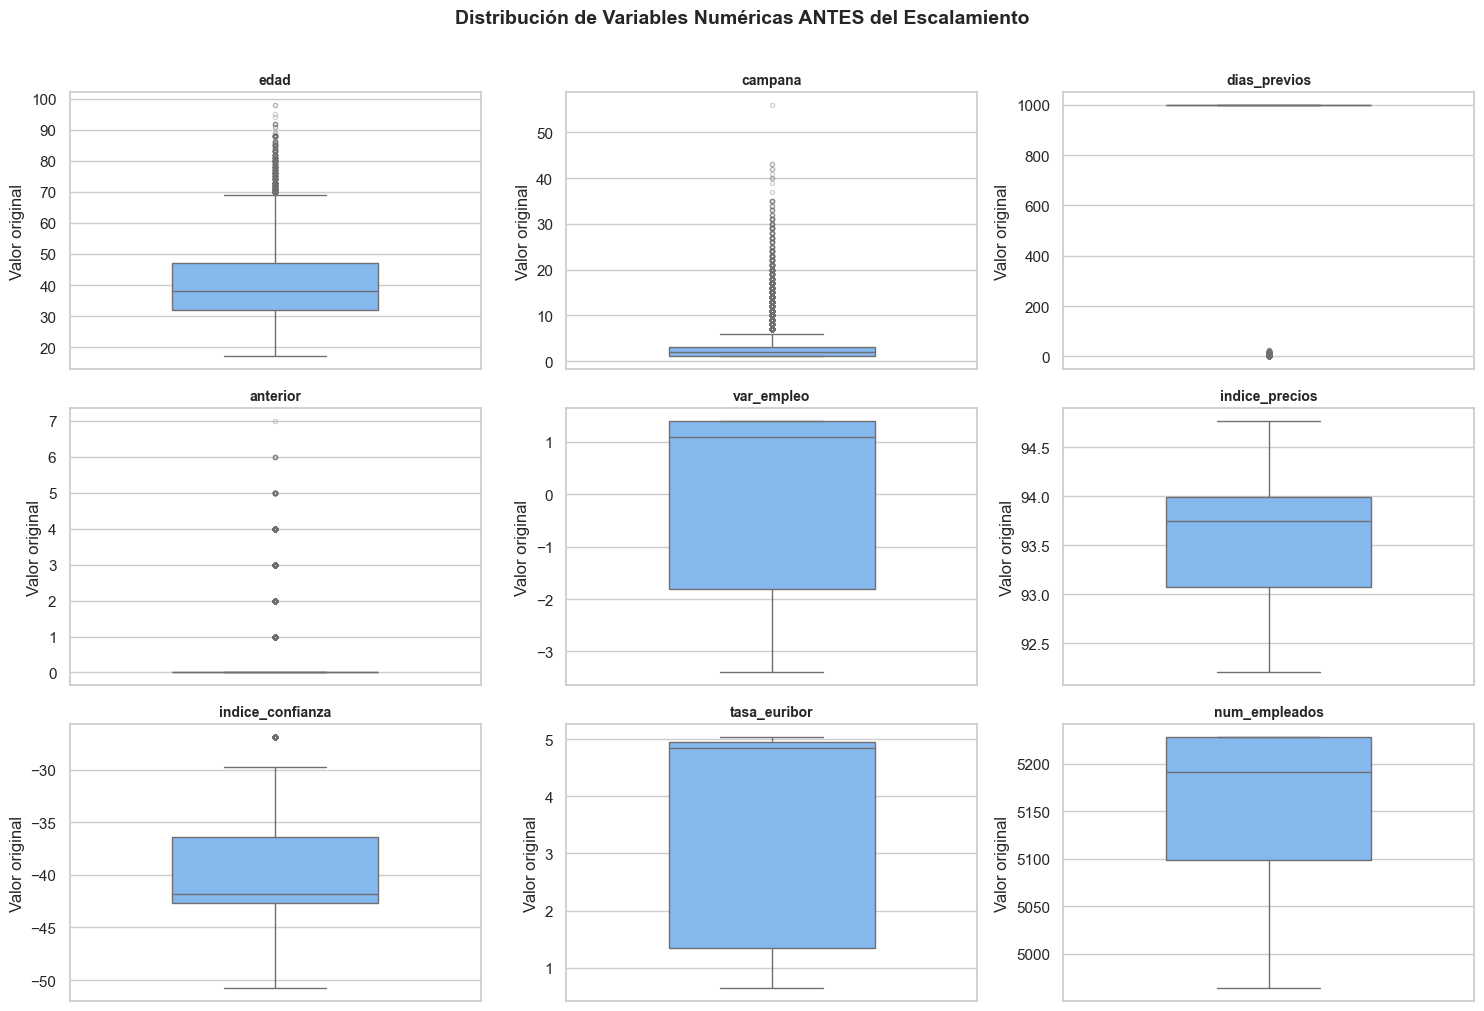

Gráfico guardado: escalamiento_boxplots_antes.png


In [21]:
# ─── GRÁFICO: Distribución ANTES del escalamiento ────────────────────────────
numeric_cols_ml = ['edad', 'campana', 'dias_previos', 'anterior',
                   'var_empleo', 'indice_precios', 'indice_confianza',
                   'tasa_euribor', 'num_empleados']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_ml):
    sns.boxplot(y=df_ml[col], ax=axes[i], color='#74b9ff', width=0.5,
                flierprops=dict(marker='o', markersize=3, alpha=0.3))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Valor original')

plt.suptitle('Distribución de Variables Numéricas ANTES del Escalamiento',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graficos/escalamiento_boxplots_antes.png', bbox_inches='tight', dpi=150)
plt.show()
print("Gráfico guardado: escalamiento_boxplots_antes.png")

In [22]:
# ─── CAPPING DE OUTLIERS (IQR) + STANDARD SCALER ────────────────────────────
def cap_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

print("=== Capping de outliers ===")
for col in ['edad', 'campana']:
    antes = df_ml[col].max()
    df_ml[col] = cap_outliers_iqr(df_ml[col])
    despues = df_ml[col].max()
    print(f"  {col}: max antes = {antes:.1f} → max después = {despues:.1f}")

# Aplicar StandardScaler
scaler = StandardScaler()
df_ml[numeric_cols_ml] = scaler.fit_transform(df_ml[numeric_cols_ml])

print("\nStandardScaler aplicado. Estadísticos (media ≈ 0, std ≈ 1):")
print(df_ml[numeric_cols_ml].describe().loc[['mean', 'std']].round(4).to_string())

=== Capping de outliers ===
  edad: max antes = 98.0 → max después = 69.5
  campana: max antes = 56.0 → max después = 6.0

StandardScaler aplicado. Estadísticos (media ≈ 0, std ≈ 1):
      edad  campana  dias_previos  anterior  var_empleo  indice_precios  indice_confianza  tasa_euribor  num_empleados
mean   0.0      0.0          -0.0       0.0        -0.0             0.0              -0.0          -0.0            0.0
std    1.0      1.0           1.0       1.0         1.0             1.0               1.0           1.0            1.0


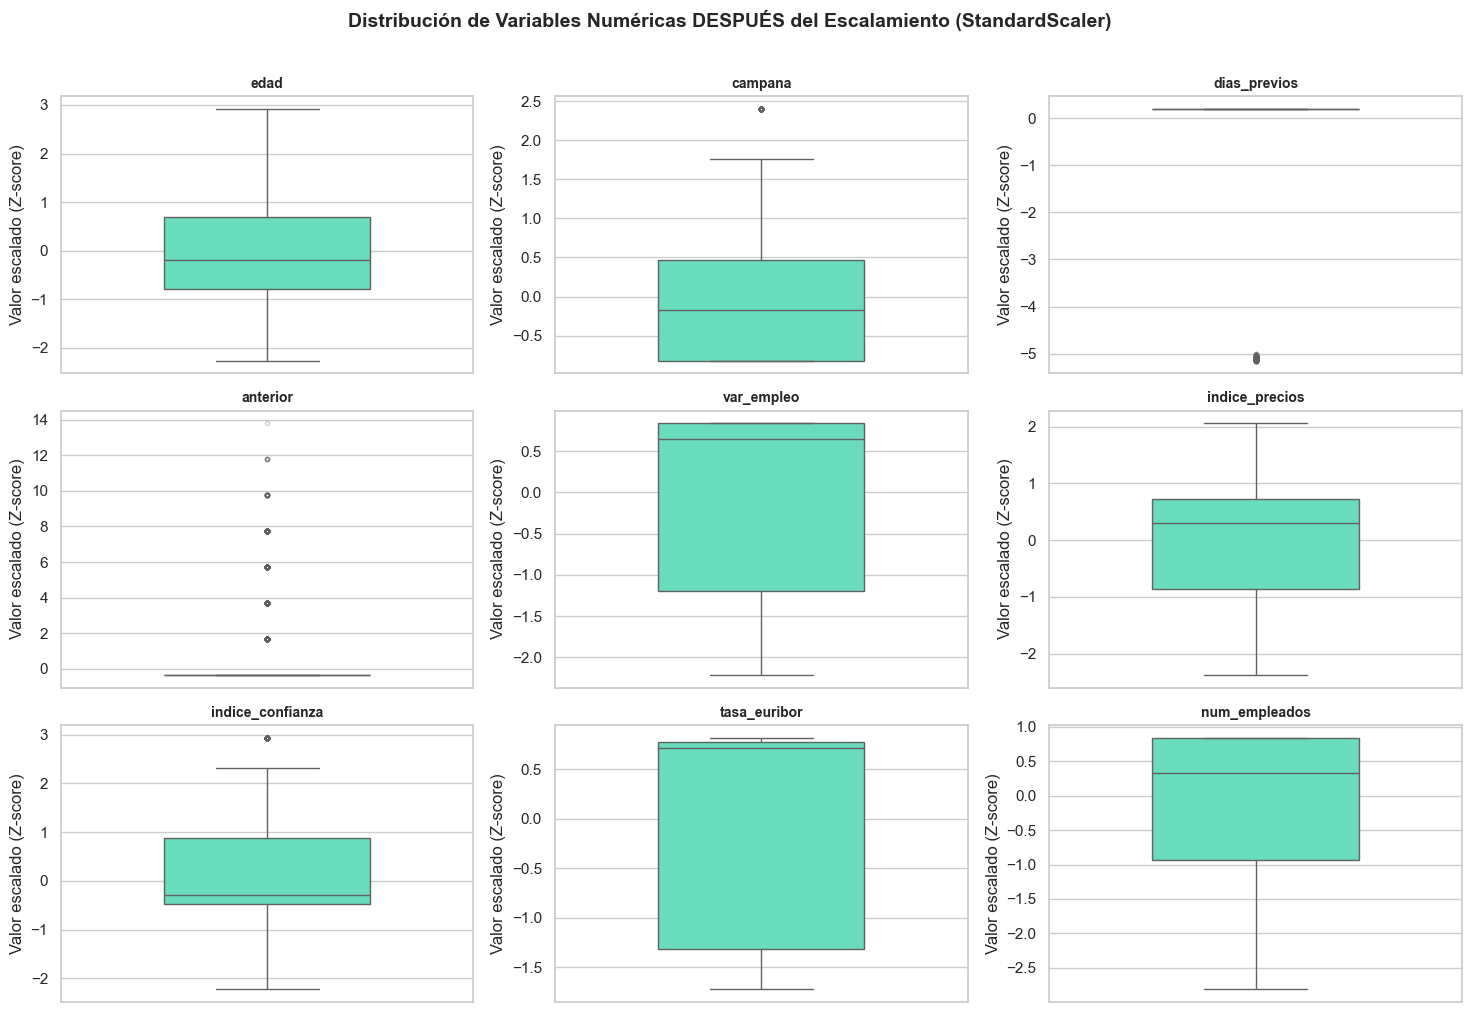

Gráfico guardado: escalamiento_boxplots_despues.png


In [23]:
# ─── GRÁFICO: Distribución DESPUÉS del escalamiento ──────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_ml):
    sns.boxplot(y=df_ml[col], ax=axes[i], color='#55efc4', width=0.5,
                flierprops=dict(marker='o', markersize=3, alpha=0.3))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Valor escalado (Z-score)')

plt.suptitle('Distribución de Variables Numéricas DESPUÉS del Escalamiento (StandardScaler)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graficos/escalamiento_boxplots_despues.png', bbox_inches='tight', dpi=150)
plt.show()
print("Gráfico guardado: escalamiento_boxplots_despues.png")

## Sección 3: Codificación de Variables Categóricas

Las variables categóricas no pueden ser procesadas directamente por los algoritmos de ML. Es necesario transformarlas a representaciones numéricas.

### Técnica seleccionada: One-Hot Encoding (OHE) con `drop_first=True`

| Variable | Tipo | Razón para OHE |
|---|---|---|
| `trabajo` | Nominal (11 categorías) | Sin orden inherente entre profesiones |
| `estado_civil` | Nominal (3 categorías) | Sin jerarquía entre casado/soltero/divorciado |
| `educacion` | Ordinal* | OHE evita asumir distancias iguales entre niveles |
| `mora` | Binaria | OHE con drop_first equivale a 0/1 |
| `vivienda` | Binaria | Idem |
| `prestamo` | Binaria | Idem |
| `contacto` | Nominal (2 categorías) | Celular vs teléfono fijo |
| `mes` | Cíclico nominal (10 meses) | OHE para no imponer orden lineal entre meses |
| `dia_de_la_semana` | Cíclico nominal (5 días) | Idem |
| `resultado_anterior` | Nominal (3 categorías) | Sin jerarquía entre éxito/fracaso/inexistente |

**`drop_first=True`**: Elimina la primera categoría de cada variable para evitar **multicolinealidad perfecta** (trampa de variable dummy), lo cual afecta la estabilidad de la Regresión Logística.

In [24]:
# ─── ONE-HOT ENCODING ────────────────────────────────────────────────────────
cat_cols_ml = df_ml.select_dtypes(include=['object']).columns.drop('deposito_plazo').tolist()

print("Variables categóricas a codificar:", cat_cols_ml)
print(f"Shape antes del OHE: {df_ml.shape}")

df_ml = pd.get_dummies(df_ml, columns=cat_cols_ml, drop_first=True)

# Convertir booleanos a int (compatibilidad con sklearn)
bool_cols = df_ml.select_dtypes(include=['bool']).columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)

print(f"Shape después del OHE: {df_ml.shape}")
print(f"Columnas totales: {df_ml.shape[1] - 1} predictores + 1 target (deposito_plazo_num)")

Variables categóricas a codificar: ['trabajo', 'estado_civil', 'educacion', 'mora', 'vivienda', 'prestamo', 'contacto', 'mes', 'dia_de_la_semana', 'resultado_anterior']
Shape antes del OHE: (41176, 21)
Shape después del OHE: (41176, 48)
Columnas totales: 47 predictores + 1 target (deposito_plazo_num)


C:\Users\Carlos\AppData\Local\Temp\ipykernel_20736\707916231.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_ml = df_ml.select_dtypes(include=['object']).columns.drop('deposito_plazo').tolist()


## Sección 4: Ingeniería de Características

La ingeniería de características crea nuevas variables a partir de las existentes para **capturar relaciones no lineales** que los algoritmos podrían no detectar automáticamente.

Las nuevas variables se crean sobre `df` (dataset original del EDA) para mantener interpretabilidad en las visualizaciones.

### Variables creadas:

| Variable nueva | Fórmula / Lógica | Justificación |
|---|---|---|
| `es_jubilado` | 1 si `trabajo == jubilado` | Los jubilados mostraron alta tasa de conversión en el EDA |
| `contactado_antes` | 1 si `dias_previos != 999` | 999 = nunca contactado. Historial previo es predictor clave |
| `contexto_favorable` | 1 si `tasa_euribor < 2` Y `var_empleo < 0` | Señal macroeconómica de bajo interés → depósitos atractivos |
| `intensidad_campana` | `campana / (anterior + 1)` | Alto ratio = cliente nuevo que requirió mucho esfuerzo |
| `grupo_edad` | bins: Joven ≤30 / Adulto 31–60 / Mayor >60 | Captura la no linealidad de la edad; jubilados (>60) tienen patrón distinto |

In [25]:
# ─── CREACIÓN DE NUEVAS VARIABLES (sobre df original) ────────────────────────
df_feat = df.copy()

# 1. Es jubilado (binaria)
df_feat['es_jubilado'] = (df_feat['trabajo'] == 'jubilado').astype(int)

# 2. Fue contactado en campaña anterior (binaria)
df_feat['contactado_antes'] = (df_feat['dias_previos'] != 999).astype(int)

# 3. Contexto macroeconómico favorable para suscribir depósitos
df_feat['contexto_favorable'] = (
    (df_feat['tasa_euribor'] < 2) & (df_feat['var_empleo'] < 0)
).astype(int)

# 4. Ratio de intensidad de campaña actual vs historial
df_feat['intensidad_campana'] = df_feat['campana'] / (df_feat['anterior'] + 1)

# 5. Grupo etario
bins = [0, 30, 60, 100]
labels = ['Joven (<=30)', 'Adulto (31-60)', 'Mayor (>60)']
df_feat['grupo_edad'] = pd.cut(df_feat['edad'], bins=bins, labels=labels, right=True)

print("Nuevas variables creadas exitosamente:")
nuevas = ['es_jubilado', 'contactado_antes', 'contexto_favorable', 'intensidad_campana', 'grupo_edad']
for v in nuevas:
    print(f"  {v}: {df_feat[v].dtype} | {df_feat[v].nunique()} valores únicos")

Nuevas variables creadas exitosamente:
  es_jubilado: int64 | 2 valores únicos
  contactado_antes: int64 | 2 valores únicos
  contexto_favorable: int64 | 2 valores únicos
  intensidad_campana: float64 | 74 valores únicos
  grupo_edad: category | 3 valores únicos


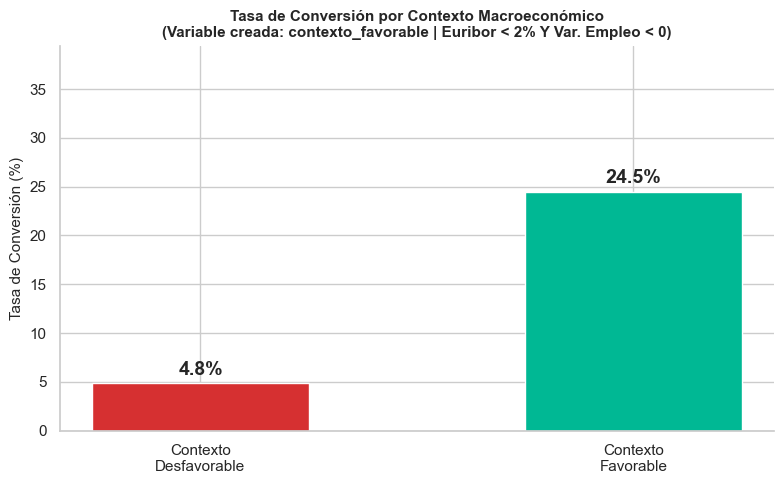

Gráfico guardado: ingenieria_conversion_por_contexto_macroeconomico.png


In [26]:
# ─── GRÁFICO: Tasa de Conversión por Contexto Macroeconómico ─────────────────
conv_contexto = df_feat.groupby('contexto_favorable')['deposito_plazo_num'].mean() * 100
etiquetas = ['Contexto\nDesfavorable', 'Contexto\nFavorable']
colores = ['#d63031', '#00b894']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(etiquetas, conv_contexto.values, color=colores, edgecolor='white', width=0.5)

for bar, val in zip(bars, conv_contexto.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Tasa de Conversión (%)', fontsize=11)
ax.set_title('Tasa de Conversión por Contexto Macroeconómico\n(Variable creada: contexto_favorable | Euribor < 2% Y Var. Empleo < 0)',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, conv_contexto.max() + 15)
sns.despine()
plt.tight_layout()
plt.savefig('graficos/ingenieria_conversion_por_contexto_macroeconomico.png', bbox_inches='tight', dpi=150)
plt.show()
print("Gráfico guardado: ingenieria_conversion_por_contexto_macroeconomico.png")

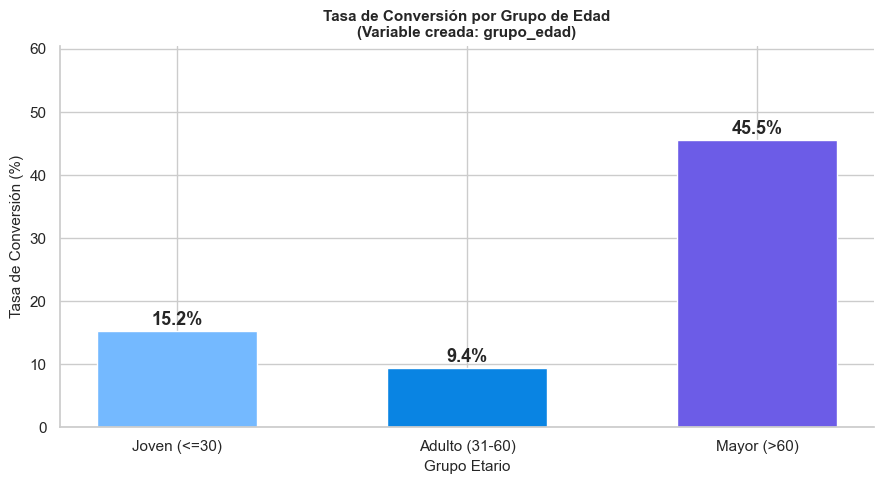

Gráfico guardado: ingenieria_conversion_por_grupo_edad.png


In [27]:
# ─── GRÁFICO: Tasa de Conversión por Grupo de Edad ───────────────────────────
conv_edad = df_feat.groupby('grupo_edad', observed=True)['deposito_plazo_num'].mean() * 100
colores_edad = ['#74b9ff', '#0984e3', '#6c5ce7']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(conv_edad.index.astype(str), conv_edad.values, color=colores_edad, edgecolor='white', width=0.55)

for bar, val in zip(bars, conv_edad.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Tasa de Conversión (%)', fontsize=11)
ax.set_xlabel('Grupo Etario', fontsize=11)
ax.set_title('Tasa de Conversión por Grupo de Edad\n(Variable creada: grupo_edad)',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, conv_edad.max() + 15)
sns.despine()
plt.tight_layout()
plt.savefig('graficos/ingenieria_conversion_por_grupo_edad.png', bbox_inches='tight', dpi=150)
plt.show()
print("Gráfico guardado: ingenieria_conversion_por_grupo_edad.png")

In [28]:
# ─── INCORPORAR NUEVAS VARIABLES AL DATASET ML ───────────────────────────────
# Las features binarias/numéricas se agregan al df_ml (ya escalado + OHE)
df_ml['es_jubilado'] = df_feat['es_jubilado'].values
df_ml['contactado_antes'] = df_feat['contactado_antes'].values
df_ml['contexto_favorable'] = df_feat['contexto_favorable'].values
df_ml['intensidad_campana'] = df_feat['intensidad_campana'].values

# grupo_edad → OHE (con drop_first para evitar multicolinealidad)
grupo_dummies = pd.get_dummies(df_feat['grupo_edad'], prefix='grupo_edad', drop_first=True)
grupo_dummies.columns = [str(c) for c in grupo_dummies.columns]
df_ml = pd.concat([df_ml.reset_index(drop=True), grupo_dummies.reset_index(drop=True)], axis=1)

print("Nuevas variables incorporadas al dataset ML:")
nuevas_ml = ['es_jubilado', 'contactado_antes', 'contexto_favorable', 'intensidad_campana'] + list(grupo_dummies.columns)
for col in nuevas_ml:
    print(f"  + {col}")

Nuevas variables incorporadas al dataset ML:
  + es_jubilado
  + contactado_antes
  + contexto_favorable
  + intensidad_campana
  + grupo_edad_Adulto (31-60)
  + grupo_edad_Mayor (>60)


## Dataset Final para Machine Learning

El pipeline de preprocesamiento produce un dataset limpio, escalado y enriquecido listo para los algoritmos de clasificación.

**Resumen del pipeline aplicado:**
1. ✅ Eliminación de duplicados  
2. ✅ Descarte de `duration` (data leaker)  
3. ✅ Imputación de unknowns por moda  
4. ✅ Capping de outliers en `edad` y `campana` (IQR × 1.5)  
5. ✅ One-Hot Encoding de variables categóricas (`drop_first=True`)  
6. ✅ StandardScaler en variables numéricas  
7. ✅ Ingeniería de características (5 variables nuevas)

In [29]:
# ─── RESUMEN DATASET FINAL ───────────────────────────────────────────────────
print("=" * 62)
print("   RESUMEN DEL DATASET FINAL PARA MACHINE LEARNING")
print("=" * 62)
print(f"  Filas:          {df_ml.shape[0]:>6,}")
print(f"  Columnas total: {df_ml.shape[1]:>6}  (predictores + target)")
print(f"  NaN totales:    {df_ml.isnull().sum().sum():>6}")
print(f"  Target:         deposito_plazo_num  (0=no, 1=si)")
print("=" * 62)
print()
print("Distribución del target:")
vc = df_ml['deposito_plazo_num'].value_counts()
for val, cnt in vc.items():
    label = 'Sí suscribe' if val == 1 else 'No suscribe'
    print(f"  {label}: {cnt:,} ({cnt/len(df_ml)*100:.1f}%)")

   RESUMEN DEL DATASET FINAL PARA MACHINE LEARNING
  Filas:          41,176
  Columnas total:     54  (predictores + target)
  NaN totales:         0
  Target:         deposito_plazo_num  (0=no, 1=si)

Distribución del target:
  No suscribe: 36,537 (88.7%)
  Sí suscribe: 4,639 (11.3%)


## Referencias

- Moro, S., Cortez, P., & Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing*. Decision Support Systems, 62, 22–31. https://doi.org/10.1016/j.dss.2014.03.001

- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830. https://scikit-learn.org/

- McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference.

- Waskom, M. (2021). *Seaborn: Statistical Data Visualization*. Journal of Open Source Software, 6(60), 3021. https://doi.org/10.21105/joss.03021